# Voting Classifier

In [40]:
from sklearn.ensemble import VotingClassifier, BaggingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [4]:
X = load_digits().data
y = load_digits().target # 손글씨 정답

In [47]:
# X, y = load_iris(return_X_y=True) 를 사용하면 직접 나누지 않아도 된다..

In [5]:
X.shape

(1797, 64)

In [9]:
X[0].reshape(-1, 8) # 8x8 배열로 확인

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

In [17]:
load_digits().images # X[0].reshape(-1, 8) 과 동일한 기능, 이미 들어가 있음

array([[[ 0.,  0.,  5., ...,  1.,  0.,  0.],
        [ 0.,  0., 13., ..., 15.,  5.,  0.],
        [ 0.,  3., 15., ..., 11.,  8.,  0.],
        ...,
        [ 0.,  4., 11., ..., 12.,  7.,  0.],
        [ 0.,  2., 14., ..., 12.,  0.,  0.],
        [ 0.,  0.,  6., ...,  0.,  0.,  0.]],

       [[ 0.,  0.,  0., ...,  5.,  0.,  0.],
        [ 0.,  0.,  0., ...,  9.,  0.,  0.],
        [ 0.,  0.,  3., ...,  6.,  0.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.]],

       [[ 0.,  0.,  0., ..., 12.,  0.,  0.],
        [ 0.,  0.,  3., ..., 14.,  0.,  0.],
        [ 0.,  0.,  8., ..., 16.,  0.,  0.],
        ...,
        [ 0.,  9., 16., ...,  0.,  0.,  0.],
        [ 0.,  3., 13., ..., 11.,  5.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.]],

       ...,

       [[ 0.,  0.,  1., ...,  1.,  0.,  0.],
        [ 0.,  0., 13., ...,  2.,  1.,  0.],
        [ 0.,  0., 16., ..., 16.,  5.,  0.

In [10]:
y[0]

np.int64(0)

In [11]:
import matplotlib.pyplot as plt

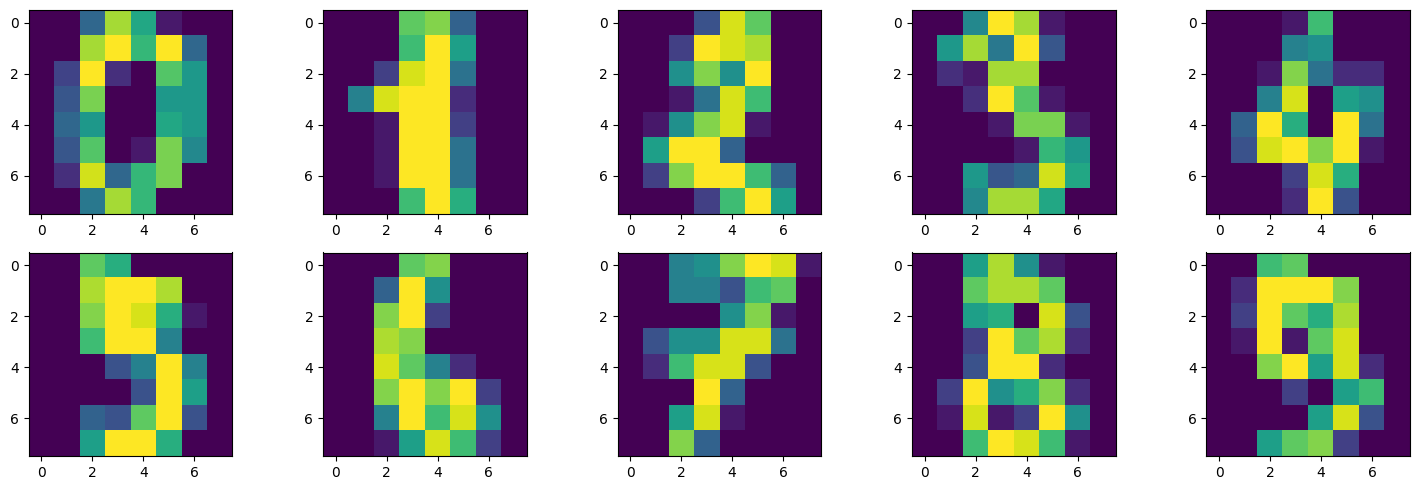

In [18]:
fig, axes = plt.subplots(2, 5, figsize=(15,5))
for ax, img, label in zip(axes.ravel(), load_digits().images[:10], y[:10]):
    ax.imshow(img)

plt.tight_layout()

In [51]:
model1 = LogisticRegression(random_state=42, max_iter=1000)
model2 = DecisionTreeClassifier(random_state=42)
model3 = SVC(probability=True, random_state=42)

In [52]:
voting_clf = VotingClassifier(
    estimators=[
        ('lr', model1),
        ('dt', model2),
        ('svc', model3)
    ],
    voting='soft'
)

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [54]:
voting_clf.fit(X_train, y_train)

,estimators,"[('lr', ...), ('dt', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


In [55]:
voting_clf.score(X_test, y_test)

0.975

In [56]:
voting_clf.predict_proba(X_test)[:5]

array([[1.49380924e-03, 5.15575103e-04, 3.83370855e-04, 4.08070751e-04,
        9.43995579e-04, 9.87516199e-04, 9.92080270e-01, 4.02240948e-04,
        1.79684100e-03, 9.88310435e-04],
       [4.84020854e-04, 1.43567144e-04, 2.08456205e-04, 1.22044641e-03,
        7.55352521e-04, 1.27477821e-02, 1.62171200e-04, 2.80800488e-04,
        6.32895433e-04, 9.83364508e-01],
       [7.88231021e-05, 4.96223303e-05, 9.52934368e-05, 9.98904674e-01,
        9.13177353e-05, 1.85608580e-04, 1.04971348e-04, 9.48395307e-05,
        1.99298909e-04, 1.95551186e-04],
       [9.78141831e-04, 8.31719201e-04, 1.24260502e-03, 1.60713332e-03,
        1.79848096e-03, 3.42153005e-03, 5.23291184e-04, 9.75766487e-01,
        2.18887979e-03, 1.16417314e-02],
       [1.39299856e-03, 1.68716192e-03, 9.58040319e-01, 2.11793580e-02,
        6.13701236e-04, 2.39513267e-03, 3.04522570e-03, 1.29198117e-03,
        7.25766363e-03, 3.09645786e-03]])

In [42]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr.score(X_test,  y_test)

0.975

In [43]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
dt.score(X_test, y_test)

0.8472222222222222

In [44]:
svc = SVC()
svc.fit(X_train, y_train)
svc.score(X_test, y_test)

0.9861111111111112

In [45]:
bc = BaggingClassifier(estimator=SVC(), n_estimators=100)
bc.fit(X_train, y_train)
bc.score(X_test, y_test)

0.9916666666666667

In [46]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf.score(X_test, y_test)

0.9722222222222222

---
## Voting 하이퍼파라미터 튜닝 - 가중치 직접 설정

In [57]:
voting_clf_weight = VotingClassifier(
    estimators=[
        ('lr', model1),
        ('dt', model2),
        ('svc', model3)
    ],
    voting='soft',
    weights=[1, 1, 3]
)

voting_clf_weight.fit(X_train, y_train)
voting_clf_weight.score(X_test, y_test)

0.9805555555555555

---
# StackingClassifier

In [58]:
from sklearn.ensemble import StackingClassifier

In [59]:
base_models = [
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42)),
    ('svc', SVC(probability=True, random_state=42))
]

meta_model = LogisticRegression(max_iter=1000, random_state=42)

In [61]:
stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5 # OOF를 사용하기 위해 필수!!
)

stacking_clf.fit(X_train, y_train)

,estimators,"[('dt', ...), ('rf', ...), ...]"
,final_estimator,LogisticRegre...ndom_state=42)
,cv,5
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2


In [62]:
stacking_clf.score(X_test, y_test)

0.9861111111111112

---
## Stacking 하이퍼파라미터 튜닝 (Grid Search)

In [63]:
from sklearn.model_selection import GridSearchCV

In [65]:
base_models = [
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42)),
    ('svc', SVC(probability=True, random_state=42))
]

stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42)
)

In [66]:
param_gird = {
    'dt__max_depth' : [3, 5, 7], # dt__ 사용해서 DecisionTree 모델의 max_depth임을 알려줌
    'rf__max_depth' : [5, 10],
    'rf__n_estimators' : [50, 100],
    'svc__C' : [0.1, 1, 10],
    'cv' : [3, 5],
    'passthrough' : [True, False],
    'final_estimator__C' : [0.1, 1, 10]
}

gs = GridSearchCV(
    stacking_clf,
    param_grid=param_gird,
    cv=3,
    n_jobs=-1,
    scoring='accuracy'
)

In [67]:
gs.fit(X_train, y_train)

,estimator,StackingClass...dom_state=42))
,param_grid,"{'cv': [3, 5], 'dt__max_depth': [3, 5, ...], 'final_estimator__C': [0.1, 1, ...], 'passthrough': [True, False], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [70]:
print(gs.best_params_)
print(gs.best_score_)

{'cv': 3, 'dt__max_depth': 3, 'final_estimator__C': 1, 'passthrough': False, 'rf__max_depth': 10, 'rf__n_estimators': 100, 'svc__C': 10}
0.9888656924147529
